Import needed libraries

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay , precision_score , recall_score , roc_auc_score , f1_score
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)

Loading and Normalizing Breast-cancer data

In [3]:
data = load_breast_cancer()
data.target = np.array([-1 if i ==0 else 1 for i in data.target])

X_temp , X_test , Y_temp , Y_test = train_test_split(data.data , data.target , test_size=0.3 ,shuffle=True , random_state=0 ,stratify=data.target)

X_train , X_val , Y_train , Y_val = train_test_split(X_temp , Y_temp , test_size=0.2 ,shuffle=True , random_state=0 , stratify=Y_temp)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [4]:
p = np.where(Y_train == 1)
n = np.where(Y_train == -1)
p_percent = len(p[0])/len(Y_train) * 100 
n_percent = len(n[0])/len(Y_train) * 100 
print(f" in our training data we have {p_percent:.1f} percent Postive samples and {n_percent:.1f} percent Negetive samples" ,  )

print("Mean of each feature : ")
print(np.int16(X_train.mean(axis=0)))
print("STD of each feature : ")
print(X_train.std(axis=0))

 in our training data we have 62.9 percent Postive samples and 37.1 percent Negetive samples
Mean of each feature : 
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
STD of each feature : 
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


Defining Adaline Class

In [ ]:
class Adaline():
    def __init__ (self , learning_rate = 0.01):
        self.lr = learning_rate
        self.SSE_list = []
        self.score_list = []


    def fit (self,x,y ,x_val ,y_val):
        self.X_train = x
        self.num_of_sample , self.num_of_features = x.shape 
        self.Y_train = y
        self.x_val = x_val
        self.y_val = y_val
        self.w=np.zeros(x.shape[1])
        self.bias = 0

    def train (self , num_of_epoch=20  , landa = 0):
        for epoch in range(num_of_epoch):
            SSE = 0
            net = np.dot(self.X_train , self.w.T) + self.bias
            h= np.sign(net)
            errors = self.Y_train - net
            SSE = np.sum((errors)**2)
            self.w += self.lr/self.num_of_sample *( np.dot(errors , self.X_train) - landa * self.w)
            self.bias +=  self.lr /self.num_of_sample * (np.sum(errors) - landa * self.bias)
            Y_p = self.predict(self.x_val)
            score = Eval(Y_p , self.y_val)
            self.SSE_list.append(SSE)
            self.score_list.append(score)
        
        return self.SSE_list , self.score_list
        
    def Online_train(self , num_of_epoch=20 , landa = 0.1): 
        for epoch in range(num_of_epoch):
            SSE = 0
            for i in range (self.num_of_sample):
                net= self.X_train[i] @ self.w.T +self.bias
                h=np.sign(net)
                SSE += (self.Y_train[i] - net)**2
                for j in range (self.num_of_features):
                    self.w[j] = self.w[j] + self.lr*((self.Y_train[i] - net)*self.X_train[i][j] - landa * self.w[j] ) 
 
                self.bias = self.bias + self.lr * ((self.Y_train[i] - net) - landa * self.bias)

            Y_p = self.predict(self.x_val)
            score = Eval(Y_p , self.y_val)
            self.SSE_list.append(SSE)
            self.score_list.append(score)
        
        return self.SSE_list , self.score_list

    def predict (self , X_test):
        return np.sign(X_test @ self.w.T + self.bias)
    
    

def Eval (Y_pred , Y_true):
    score = np.equal(Y_pred , Y_true)
    score = np.sum(score)/len(Y_true)
    return score

Now we’ll test different learning rates and select the best-performing model.

In [6]:
learning_rates = [0.001 , 0.005 , 0.02 , 0.1 ,0.15]
num_of_epochs = 50
SSEs = []
SCOREs = []
max_score = 0
best_model =Adaline()
for lr in learning_rates:
    model =Adaline(learning_rate=lr)
    model.fit(X_train , Y_train , X_val ,Y_val)
    training_sse , training_score = model.train(num_of_epochs)
    SSEs.append(training_sse)
    SCOREs.append(training_score)
    y_pred = model.predict(X_test)
    score = Eval(y_pred , Y_test)
    print(score)
    if score > max_score :
        best_model = model
        max_score = score






0.9122807017543859
0.9122807017543859
0.9415204678362573
0.9532163742690059
0.17543859649122806


We can plot the results of different models

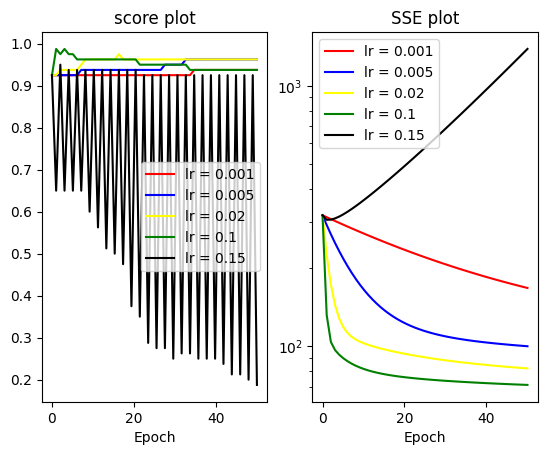

In [ ]:
epochs = np.linspace(0,num_of_epochs,num_of_epochs)
plt.subplot(1,2,1)
plt.plot(epochs , SCOREs[0] ,c='red' , label = 'lr = 0.001')
plt.plot(epochs , SCOREs[1] ,c='blue' , label = 'lr = 0.005')
plt.plot(epochs , SCOREs[2] ,c='yellow' , label = 'lr = 0.02')
plt.plot(epochs , SCOREs[3] ,c='green' , label = 'lr = 0.1')
plt.plot(epochs , SCOREs[4] ,c='black' , label = 'lr = 0.15')
plt.title("score plot")
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs , SSEs[0] ,c='red' , label = 'lr = 0.001')
plt.plot(epochs , SSEs[1] ,c='blue', label = 'lr = 0.005')
plt.plot(epochs , SSEs[2] ,c='yellow', label = 'lr = 0.02')
plt.plot(epochs , SSEs[3] ,c='green' , label = 'lr = 0.1')
plt.plot(epochs , SSEs[4] ,c='black' , label = 'lr = 0.15')
plt.title("SSE plot")
plt.xlabel('Epoch')
plt.yscale('log')


plt.legend()
plt.show()

It’s time to select the best-performing model to continue our work

In [8]:
y_pred = best_model.predict(X_test)
score = Eval(y_pred , Y_test)
print(score)

0.9532163742690059


precision : 0.938
recall : 0.991 
ROC_AUC : 0.941 
F1 : 0.964


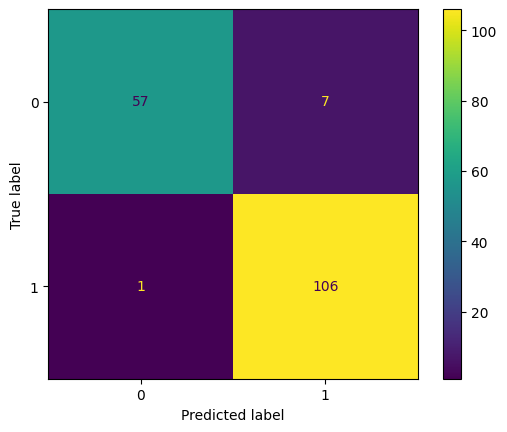

In [9]:
cm = confusion_matrix(Y_test , y_pred)

precision = precision_score(Y_test ,y_pred)
recall = recall_score(Y_test , y_pred)
roc_auc =roc_auc_score(Y_test , y_pred)
f1 = f1_score(Y_test , y_pred)


print(f"precision : {precision:.3f}"  )
print(f"recall : {recall:.3f} "  )
print(f"ROC_AUC : {roc_auc:.3f} " )
print(f"F1 : {f1:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Dimension reduction with PCA

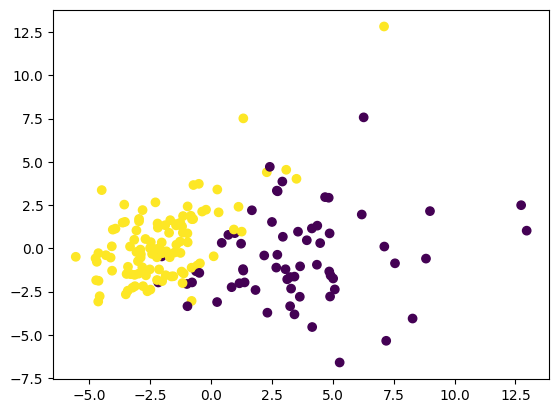

In [10]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_val = pca.transform(X_val)
plt.scatter(X_test_pca[:,0] , X_test_pca[:,1] , c=Y_test)
plt.show()

now we use 2D X_train to get weights and bias of Adaline boundry

In [11]:
X_train_pca = scaler.fit_transform(X_train_pca)
X_test_pca = scaler.transform(X_test_pca)
X_val = scaler.transform(X_val)
model = Adaline(learning_rate=0.001)
model.fit(X_train_pca , Y_train ,X_val , Y_val)
model.train()
weights = model.w
bias = model.bias

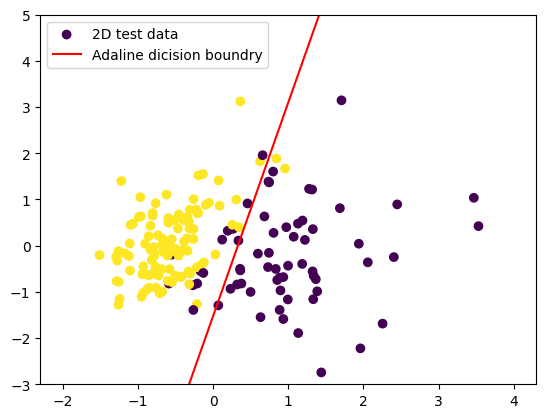

In [ ]:
X_space = np.linspace(-2,4,100)
X1_space = -(weights[0]*X_space + bias)/weights[1]
plt.scatter(X_test_pca[:,0] , X_test_pca[:,1] , c=Y_test , label = "2D test data")
plt.plot(X_space , X1_space , color='red', label = "Adaline dicision boundry")
plt.ylim(-3 , 5)
plt.legend()
plt.show()

some example for False postive and False negetive

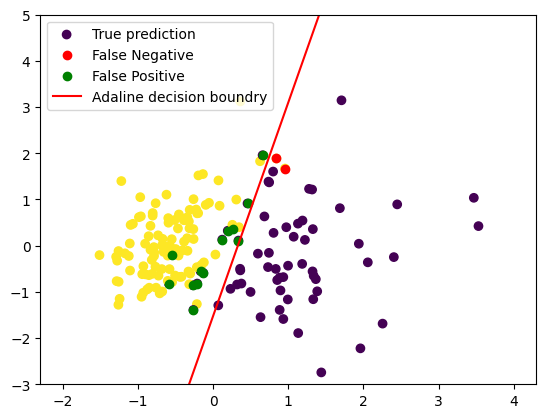

[[-1.21025703e+00 -9.27976757e-01 -1.12647585e+00 -9.87200152e-01
   7.98501579e-01  1.01585477e+00  4.07961297e+00  7.39119428e-01
   2.69095368e+00  4.15554367e+00  1.61601836e+00  2.59469430e+00
   6.38780382e-01  2.25616606e-01  1.19475955e+00  3.82549217e+00
   1.27676763e+01  6.43026019e+00  1.71310083e+00  1.05464856e+01
  -1.04923084e+00 -1.00979280e+00 -1.04577323e+00 -8.50353071e-01
  -8.91631697e-02  1.22597746e-01  2.58279881e+00  6.30685164e-01
   3.28722878e-01  2.24671746e+00]
 [ 8.03163855e-02  7.12088479e-02  1.63229357e-01 -1.45125715e-02
  -5.79807885e-01  1.15908268e+00  5.83420582e-01  4.21765333e-01
  -3.51377998e-01  1.25541932e+00  1.83127762e+00  9.82088616e-01
   7.87995391e-01  8.45872839e-01  2.03280819e-01  4.40462505e+00
   2.34935154e+00  2.47733882e+00  2.33115047e+00  7.71519266e+00
  -9.71614974e-02 -5.85189732e-01 -1.61557691e-01 -1.96966661e-01
  -1.36649071e+00 -6.48786103e-02 -2.57892026e-01 -1.86334782e-01
  -1.00664255e+00  1.96974824e-01]
 [ 3.8

In [13]:
y_pred_pca = model.predict(X_test_pca)
FN_idx = np.where((Y_test == 1) & (y_pred_pca == -1 ))
FP_idx = np.where((Y_test == -1) & (y_pred_pca == 1))

X_test_FN = X_test[FN_idx]
X_test_FP = X_test[FP_idx]


X_space = np.linspace(-2,4,100)
X1_space = -(weights[0]*X_space + bias)/weights[1]
plt.scatter(X_test_pca[:,0] , X_test_pca[:,1] , c=Y_test  , label = "True prediction")
plt.scatter(X_test_pca[FN_idx,0] , X_test_pca[FN_idx,1] , c='red' , label = "False Negative")
plt.scatter(X_test_pca[FP_idx,0] , X_test_pca[FP_idx,1] , c='green' , label = "False Positive" )
plt.plot(X_space , X1_space , color='red', label = "Adaline decision boundry")
plt.ylim(-3 , 5)
plt.legend()
plt.show()

print(X_test_FN)
print(X_test_FP)

Now we use Logestic regression

In [14]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression()
log_reg.fit(X_train , Y_train)
y_pred_reg = log_reg.predict(X_test)

ac = accuracy_score(Y_test , y_pred_reg)

print(ac)

0.9473684210526315


In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

LDA = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = LDA.fit_transform(X_train , Y_train)
X_test_lda = LDA.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_lda , Y_train)
y_pred_lda = log_reg.predict(X_test_lda)

ac = accuracy_score ( Y_test , y_pred_lda)
print(ac)

0.9473684210526315
